In [2]:
%load_ext autoreload
%autoreload 2
import torch
from torch import nn
from Systems import RevDuff
import numpy as np
from NN import Main_Network, NN
import matplotlib.pyplot as plt
from Dataset import DataSet
from Normalizer import Normalizer
from Trainer import Trainer
import scipy.io as spio
from Observer import System_z, Observer
from Observer_old import Observer as Observer_old
import torch.nn.functional as F

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


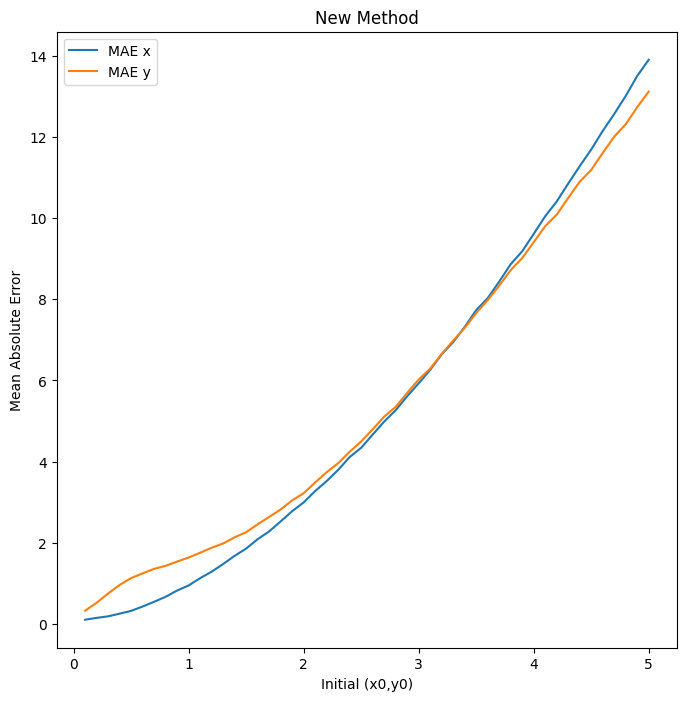

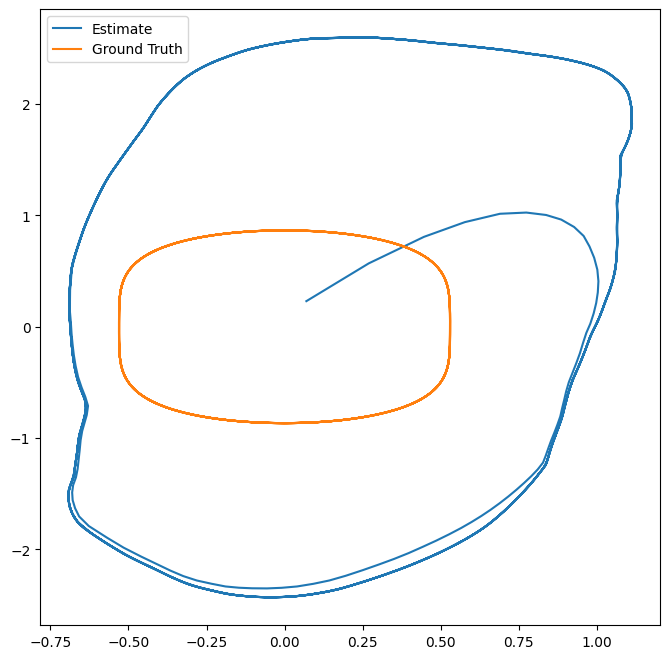

In [15]:
#------------- RevDuff ------------- 
M5_diag = np.diag([-1,-2,-3,-4,-5])    # Choose M matrix
K5_diag = np.array([[1,1,1,1,1]]).T    # Choose K matrix

revduff = RevDuff(5, add_noise=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N = 1000
a = 0
b = 50

model = torch.load('models/old_method', map_location=torch.device('cpu'))

observer2 = Observer_old(revduff, M5_diag, K5_diag, model, a, b, N, init_z_zero=True)

initial_conds = np.arange(0.1, 5.1, 0.1)
MAE_x_list_new = []
MAE_y_list_new = []

for ic in initial_conds:
    ic = np.array([[ic, ic]])
    #sys_dim5.toggle_noise()
    x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
    MAE_x = np.mean(error[0][:,0])
    MAE_y = np.mean(error[0][:,1])
    MAE_x_list_new.append(MAE_x)
    MAE_y_list_new.append(MAE_y)

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(initial_conds, MAE_x_list_new, label = 'MAE x')
plt.plot(initial_conds, MAE_y_list_new, label = 'MAE y')
plt.legend()
plt.title('New Method')
plt.xlabel('Initial (x0,y0)')
plt.ylabel('Mean Absolute Error')
plt.show()

ic = np.array([[0.5, 0.5]])
#sys_dim5.toggle_noise()
x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
fig = plt.figure(figsize = (8,8), facecolor='w')
p1, = plt.plot(x_hat[:,0], x_hat[:,1])
p2, = plt.plot(x[:,0], x[:,1])
plt.legend([p1, p2], ['Estimate', 'Ground Truth'])
plt.show()